# Modeling data from Liu et al.'s paper

This notebook models the data from this [paper](https://jitc.bmj.com/content/10/12/e005360).

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Defining and simulating the model

Here we will be setting up and simulating the differential equations using ```scipy.integrate.odeint```. From the paper there are 4 models to construct:
- CD19+ B-ALL Cell
- CAR T-cell activation
- Non-Activated CAR T-cell
- CD19+ and CD19- relapse

In [3]:
def cd19_b_all_cell(np_cells, nTA, params):
    """
    Calculates the derivative of CD19⁺ B-ALL cells.
    """
    r_p, n_c, e, K_p = params
    dnp_dt = r_p * (1 - np_cells / n_c) * np_cells - e * (np_cells / (np_cells + K_p)) * nTA
    return dnp_dt

In [4]:
def cart_activation(np_cells, nTA, nTN, params):
    """
    Calculates the derivative of activated CAR T-cells.
    """
    r_TA, K_r, k_A, K_A, l_TA = params
    dnTA_dt = r_TA * (np_cells / (np_cells + K_r)) * nTA + k_A * (np_cells / (np_cells + K_A)) * nTN - l_TA * nTA
    return dnTA_dt

In [5]:
def non_activated(np_cells, nTN, params):
    """
    Calculates the derivative of non-activated CAR T-cells.
    """
    k_A, K_A, l_TN = params
    dnTN_dt = -k_A * (np_cells / (np_cells + K_A)) * nTN - l_TN * nTN
    return dnTN_dt


In [6]:
def relapse(np_cells, nN, nTA, params):
    """
    Calculates the derivative of CD19⁻ tumor cells.
    """
    r_N, n_c, k_m, e, k_b, K_N = params
    if k_b == 0:
        term = 0
    else:
        term = (e / k_b) * (nN / (nN + K_N)) * nTA
    dnN_dt = r_N * (1 - nN / n_c) * nN + k_m * np_cells - term
    return dnN_dt

In [7]:
def car_t_cell_model(y, t, params):
    np_cells, nTA, nTN, nN = y
    
    # Unpack parameters for each function
    # [r_p, n_c, e, K_p]
    params_cd19 = params[:4]
    # [r_TA, K_r, k_A, K_A, l_TA]
    params_activation = params[4:9]
    # [k_A, K_A, l_TN]
    params_non_activated = [params[6], params[7], params[9]]
    # [r_N, n_c, k_m, e, k_b, K_N]
    params_relapse = params[10:]
    
    # Compute each derivative
    dnp_dt = cd19_b_all_cell(np_cells, nTA, params_cd19)
    dnTA_dt = cart_activation(np_cells, nTA, nTN, params_activation)
    dnTN_dt = non_activated(np_cells, nTN, params_non_activated)
    dnN_dt = relapse(np_cells, nN, nTA, params_relapse)
    
    return [dnp_dt, dnTA_dt, dnTN_dt, dnN_dt]

In [8]:
def simulate_car_t_cell_model(y0, params, t):
    """Simulates the CAR T-cell therapy model over a specified time period."""
    results = odeint(car_t_cell_model, y0, t, args=(params,))
    return results

In [9]:
params_cr = [
    # For cd19_b_all_cell
    0.069,    # r_p
    2939.1,   # n_c
    22.72,    # e
    5891.5,   # K_p
    # For cart_activation
    1.62,     # r_TA
    637.64,   # K_r
    0.65,     # k_A
    1808.0,   # K_A
    0.12,     # l_TA
    # For non_activated
    3e-5,     # l_TN
    # For relapse
    0,        # r_N
    2939.1,   # n_c (same as before)
    0,        # k_m
    22.72,    # e (same as before)
    0,        # k_b
    0         # K_N
]

In [10]:
y0_cr = [
    2200.24,  # np_cells (CD19⁺ B-ALL cells)
    0,        # nTA (Activated CAR T-cells)
    16.5,     # nTN (Non-Activated CAR T-cells)
    0         # nN (CD19⁻ tumor cells)
]

In [11]:
# Parameters and initial conditions for Non-Response (NR)
params_nr = [
    # For cd19_b_all_cell
    0.08,      # r_p
    6101.58,   # n_c
    6.58,      # e
    7067.07,   # K_p
    # For cart_activation
    0.99,      # r_TA
    3431.65,   # K_r
    0.31,      # k_A
    0.0052,    # K_A
    0.55,      # l_TA
    # For non_activated
    9.2e-4,    # l_TN
    # For relapse
    0,         # r_N
    6101.58,   # n_c (same as before)
    0,         # k_m
    6.58,      # e (same as before)
    0,         # k_b
    0          # K_N
]

In [12]:
y0_nr = [
    589.676,  # np_cells (CD19⁺ B-ALL cells)
    0,        # nTA (Activated CAR T-cells)
    71.45,    # nTN (Non-Activated CAR T-cells)
    0         # nN (CD19⁻ tumor cells)
]

In [13]:
# Parameters and initial conditions for CD19⁺ Relapse
params_cd19_pos_relapse = [
    # For cd19_b_all_cell
    0.21,     # r_p
    19877.4,  # n_c
    20.31,    # e
    1050.19,  # K_p
    # For cart_activation
    0.99,     # r_TA
    1983.64,  # K_r
    0.44,     # k_A
    54.68,    # K_A
    0.12,     # l_TA
    # For non_activated
    6e-7,     # l_TN
    # For relapse
    0,        # r_N
    19877.4,  # n_c (same as before)
    0,        # k_m
    20.31,    # e (same as before)
    0,        # k_b
    0         # K_N
]

In [14]:
y0_cd19_pos_relapse = [
    1764.25,  # np_cells (CD19⁺ B-ALL cells)
    0,        # nTA (Activated CAR T-cells)
    12.26,    # nTN (Non-Activated CAR T-cells)
    0         # nN (CD19⁻ tumor cells)
]

In [15]:
# Parameters and initial conditions for CD19⁻ Relapse
params_cd19_neg_relapse = [
    # For cd19_b_all_cell
    0.071,     # r_p
    2585.74,   # n_c
    19.34,     # e
    11040.05,  # K_p
    # For cart_activation
    1.5,       # r_TA
    1360.54,   # K_r
    0.58,      # k_A
    11883.73,  # K_A
    0.11,      # l_TA
    # For non_activated
    2e-7,      # l_TN
    # For relapse
    0.1,       # r_N
    2585.74,   # n_c (same as before)
    1.5e-7,    # k_m
    19.34,     # e (same as before)
    7.9,       # k_b
    16956.03   # K_N
]

In [16]:
y0_cd19_neg_relapse = [
    1467.01,  # np_cells (CD19⁺ B-ALL cells)
    0,        # nTA (Activated CAR T-cells)
    8.97,     # nTN (Non-Activated CAR T-cells)
    19.89     # nN (CD19⁻ tumor cells)
]

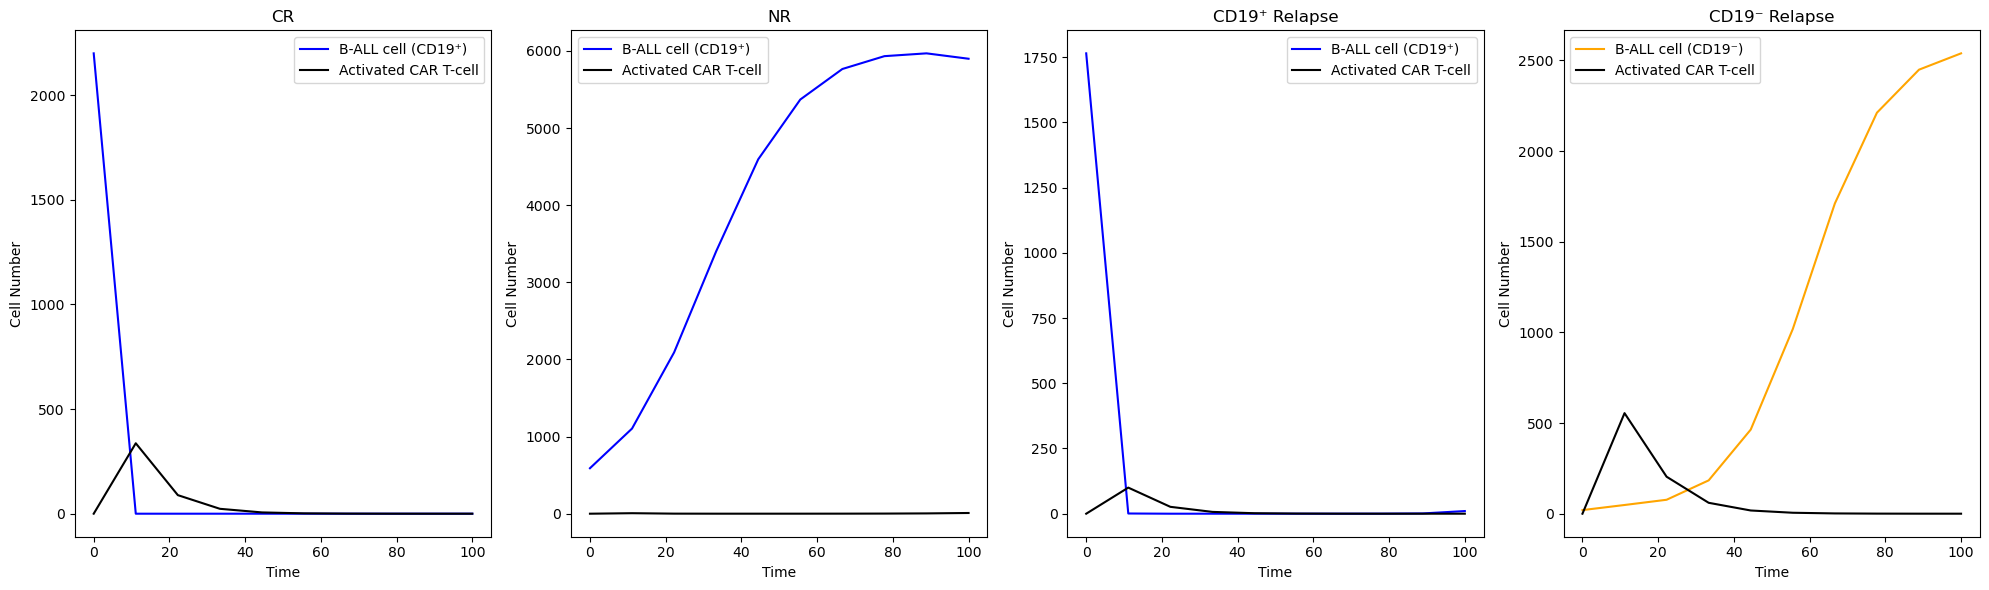

In [21]:
# Simulation and plotting
t = np.linspace(0, 100, 10)

results_cr = simulate_car_t_cell_model(y0_cr, params_cr, t)
results_nr = simulate_car_t_cell_model(y0_nr, params_nr, t)
results_cd19_pos_relapse = simulate_car_t_cell_model(y0_cd19_pos_relapse, params_cd19_pos_relapse, t)
results_cd19_neg_relapse = simulate_car_t_cell_model(y0_cd19_neg_relapse, params_cd19_neg_relapse, t)

fig, axs = plt.subplots(1, 4, figsize=(20, 6))

# Plot for CR (Complete Remission)
axs[0].plot(t, results_cr[:, 0], label='B-ALL cell (CD19⁺)', color='blue')
axs[0].plot(t, results_cr[:, 1], label='Activated CAR T-cell', color='black')
axs[0].set_title('CR')
axs[0].set_xlabel('Time')
axs[0].set_ylabel('Cell Number')
axs[0].legend()

# Plot for NR (Non-Response)
axs[1].plot(t, results_nr[:, 0], label='B-ALL cell (CD19⁺)', color='blue')
axs[1].plot(t, results_nr[:, 1], label='Activated CAR T-cell', color='black')
axs[1].set_title('NR')
axs[1].set_xlabel('Time')
axs[1].set_ylabel('Cell Number')
axs[1].legend()

# Plot for CD19⁺ Relapse
axs[2].plot(t, results_cd19_pos_relapse[:, 0], label='B-ALL cell (CD19⁺)', color='blue')
axs[2].plot(t, results_cd19_pos_relapse[:, 1], label='Activated CAR T-cell', color='black')
axs[2].set_title('CD19⁺ Relapse')
axs[2].set_xlabel('Time')
axs[2].set_ylabel('Cell Number')
axs[2].legend()

# Plot for CD19⁻ Relapse
axs[3].plot(t, results_cd19_neg_relapse[:, 3], label='B-ALL cell (CD19⁻)', color='orange')
axs[3].plot(t, results_cd19_neg_relapse[:, 1], label='Activated CAR T-cell', color='black')
axs[3].set_title('CD19⁻ Relapse')
axs[3].set_xlabel('Time')
axs[3].set_ylabel('Cell Number')
axs[3].legend()

plt.tight_layout()
plt.show()

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# Simulation
t = np.linspace(0, 400, 4000)  # Extend to 400 days

results_cr = simulate_car_t_cell_model(y0_cr, params_cr, t)
results_nr = simulate_car_t_cell_model(y0_nr, params_nr, t)
results_cd19_pos_relapse = simulate_car_t_cell_model(y0_cd19_pos_relapse, params_cd19_pos_relapse, t)
results_cd19_neg_relapse = simulate_car_t_cell_model(y0_cd19_neg_relapse, params_cd19_neg_relapse, t)

# Plotting
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
axs = axs.flatten()

titles = ['CR', 'NR', 'CD19⁺ Relapse', 'CD19⁻ Relapse']
results = [results_cr, results_nr, results_cd19_pos_relapse, results_cd19_neg_relapse]

for i, (ax, title, result) in enumerate(zip(axs, titles, results)):
    ax.semilogy(t, result[:, 0], label='B-ALL cell (CD19⁺)', color='blue')
    ax.semilogy(t, result[:, 1], label='Activated CAR T-cell', color='red')
    
    if i == 3:  # For CD19⁻ Relapse
        ax.semilogy(t, result[:, 3], label='B-ALL cell (CD19⁻)', color='green')
    
    ax.set_title(title)
    ax.set_xlabel('Time (days)')
    ax.set_ylabel('Cell Number')
    ax.set_ylim(9, 10)
    ax.grid(True, which="both", ls="-", alpha=0.2)
    
    # Add horizontal lines for 5% and 25% tumor burden
    ax.axhline(y=0.05*y0_cr[0], color='gray', linestyle='--', alpha=0.5)
    ax.axhline(y=0.25*y0_cr[0], color='gray', linestyle='--', alpha=0.5)
    
    # Add text labels
    ax.text(350, result[0, 0], 'CD19⁺ B-ALL', color='blue', ha='right', va='center')
    ax.text(350, result[0, 1], 'CAR T-cell', color='red', ha='right', va='center')
    if i == 3:
        ax.text(350, result[0, 3], 'CD19⁻ B-ALL', color='green', ha='right', va='center')

plt.tight_layout()
plt.show()

/var/folders/8y/57d0gjj96nz3fb3db518g2kr0000gn/T/ipykernel_52681/4259633333.py:42: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


ValueError: Image size of 1041x7675041 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 1200x1000 with 4 Axes>